In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

df = pd.read_csv('../data/raw_sales_data.csv')
print(df.shape)
print(df.isnull().sum())

# Fix inconsistent product names
df['Product'] = df['Product'].str.title()

# Fill missing Units_Sold with median per product
df['Units_Sold'] = df.groupby('Product')['Units_Sold'].transform(lambda x: x.fillna(x.median()))

# Fill missing Region/Salesperson with 'Unknown'
df['Region'] = df['Region'].fillna('Unknown')
df['Salesperson'] = df['Salesperson'].fillna('Unknown')

# Create Revenue column
df['Revenue'] = df['Units_Sold'] * df['Unit_Price']
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

df.to_csv('../data/cleaned_sales_data.csv', index=False)
print("Cleaned. Shape:", df.shape)

(200, 6)
Date            0
Product         0
Units_Sold     15
Unit_Price      0
Region         46
Salesperson    42
dtype: int64
Cleaned. Shape: (200, 8)


In [2]:
# Top products by revenue
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print(top_products)

# Monthly revenue trend
monthly = df.groupby('Month')['Revenue'].sum()
print(monthly)

# Region breakdown
region = df.groupby('Region')['Revenue'].sum()
print(region)

Product
Laptop        492493.0
Headphones    410100.5
Charger       397536.0
Phone         333304.5
Tablet        291486.0
Name: Revenue, dtype: float64
Month
2024-01     83690.5
2024-02    143688.0
2024-03     93981.5
2024-04    123663.0
2024-05    151237.0
2024-06    159039.0
2024-07    191259.0
2024-08    147719.5
2024-09    276061.5
2024-10    155774.5
2024-11     86624.0
2024-12    124990.0
2025-01    159720.0
2025-02     27472.5
Freq: M, Name: Revenue, dtype: float64
Region
East       336337.0
North      388501.5
South      369524.5
Unknown    503019.0
West       327538.0
Name: Revenue, dtype: float64


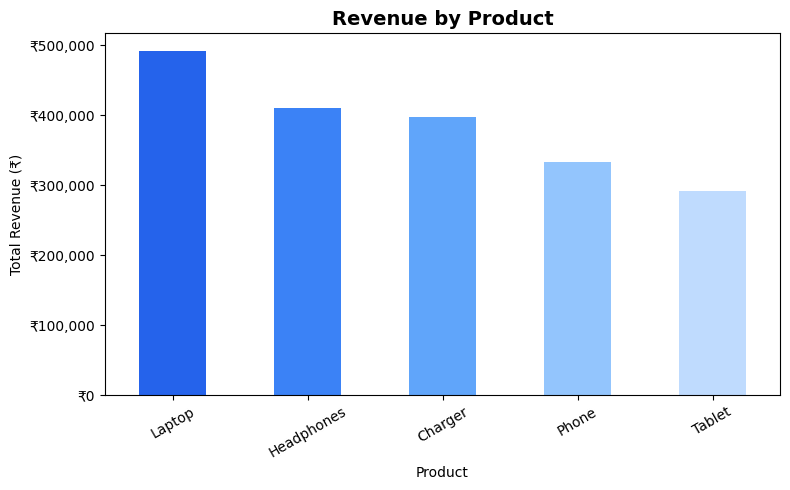

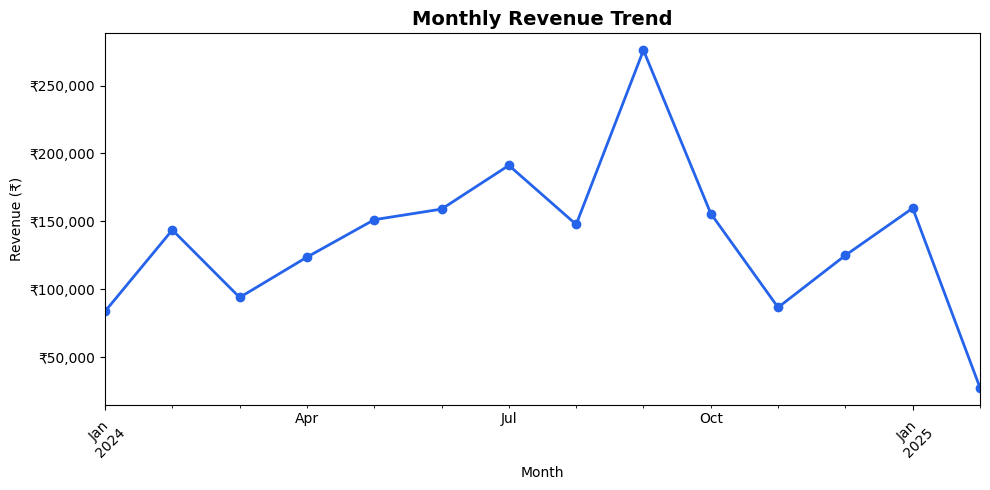

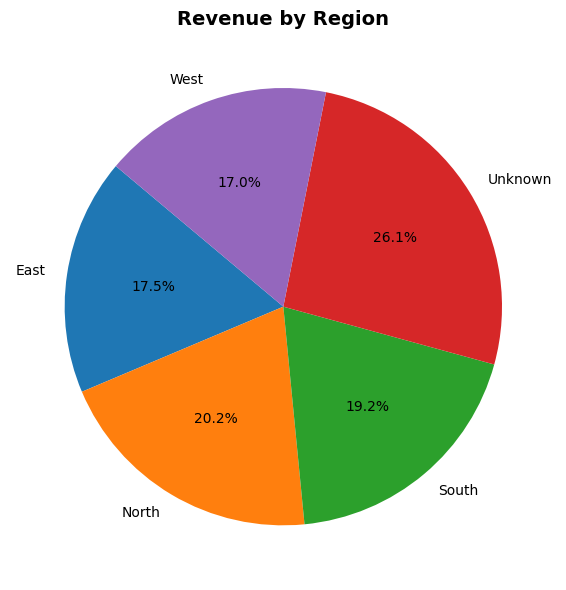

In [3]:
os.makedirs('../visuals', exist_ok=True)

# Chart 1: Top Products Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
top_products.plot(kind='bar', ax=ax, color=['#2563EB','#3B82F6','#60A5FA','#93C5FD','#BFDBFE'])
ax.set_title('Revenue by Product', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../visuals/revenue_by_product.png', dpi=150)
plt.show()

# Chart 2: Monthly Revenue Line Chart
fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind='line', ax=ax, marker='o', color='#2563EB', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_trend.png', dpi=150)
plt.show()

# Chart 3: Region Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
region.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=140)
ax.set_title('Revenue by Region', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visuals/region_pie.png', dpi=150)
plt.show()